<a href="https://colab.research.google.com/github/AchiengJoy/fraud-detection-ml-banking/blob/main/online_payment_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Online payment fraud detection

We are living in the digital world where people started approaching towards current technologies. They make our work easy and its reliable.

Online payment is one of the scenarios where people started using in recent years. Just one click! one Tap! makes our work easier and faster.
As much as we know about the merits of online payment, there are fraudsters who try to loot money from people with different techniques.

With the increase of online payment now-a-days, the online payment fraud has also been rising and it's actually a major concern among the people who are not aware of the current technologies.

Let's analyze about the online payment fraud detection dataset taken from Kaggle and provide insights on this!!

##  Business Problem

Financial institutions process millions of transactions daily, making manual fraud detection inefficient.

The key question is:

> Which transactions are most likely to be fraudulent?

Answering this enables proactive fraud prevention and risk mitigation.

In [ ]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
%matplotlib inline

# To scale the data using Standard Scaler
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

# Algorithms to use
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics to evaluate the model
from sklearn import metrics
from sklearn.metrics import classification_report, precision_recall_curve, recall_score, precision_score, accuracy_score, f1_score
from sklearn.metrics import confusion_matrix

import scipy.stats as stats

# For tuning the model
from sklearn.model_selection import GridSearchCV

# To ignore warnings
import warnings
warnings.filterwarnings("ignore")

Getting the data from csv

In [ ]:
# Load and use
fraud_df = pd.read_csv('https://media.githubusercontent.com/media/Vaibhav-kesarwani/Online_Payment_Fraud_Detection/refs/heads/main/onlinefraud.csv')

In [ ]:
# Copying data to another variable to avoid any changes to the original data# Copying data to another variable to avoid any changes to the original data
df = fraud_df.copy()


In [ ]:
df.head(15)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [ ]:
df.shape

(6362620, 11)

#### Columns in the dataset

**step:** represents a unit of time where 1 step equals 1 hour

**type:** type of online transaction

**amount:** the amount of the transaction

**nameOrig:** customer starting the transaction


**oldbalanceOrg:** balance before the transaction

**newbalanceOrig:** balance after the transaction

**nameDest:** recipient of the transaction

**oldbalanceDest:** initial balance of recipient before the transaction

**newbalanceDest:** the new balance of recipient after the transaction

**isFraud:** fraud transaction

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


Checking for missing values

In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


Its a good thing that there is no missing values!



Checking values for few columns

In [ ]:
df.nameOrig.value_counts()

,count
nameOrig,
C1530544995,3
C545315117,3
C724452879,3
C1784010646,3
C1677795071,3
...,...
C1567523029,1
C644777639,1
C1256645416,1


In [ ]:
df.nameDest.value_counts()

,count
nameDest,
C1286084959,113
C985934102,109
C665576141,105
C2083562754,102
C248609774,101
...,...
M367627425,1
M1902904124,1
M242332837,1


In [ ]:
df.type.value_counts()

,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


In [ ]:
df.isFlaggedFraud.value_counts()

,count
isFlaggedFraud,
0,6362604
1,16


In [ ]:
df.isFraud.value_counts()

,count
isFraud,
0,6354407
1,8213


## Exploratory Data Analysis

This section explores patterns that distinguish fraudulent transactions from legitimate ones.

Focus areas include:
- transaction amount  
- transaction type  
- account balance changes  
- time-based patterns  

#### Univariate Analysis


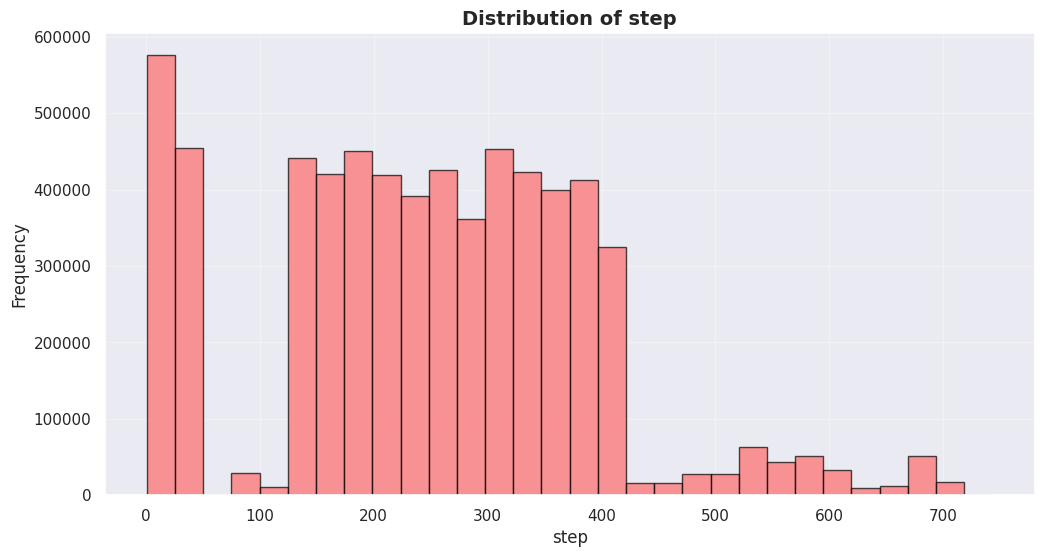

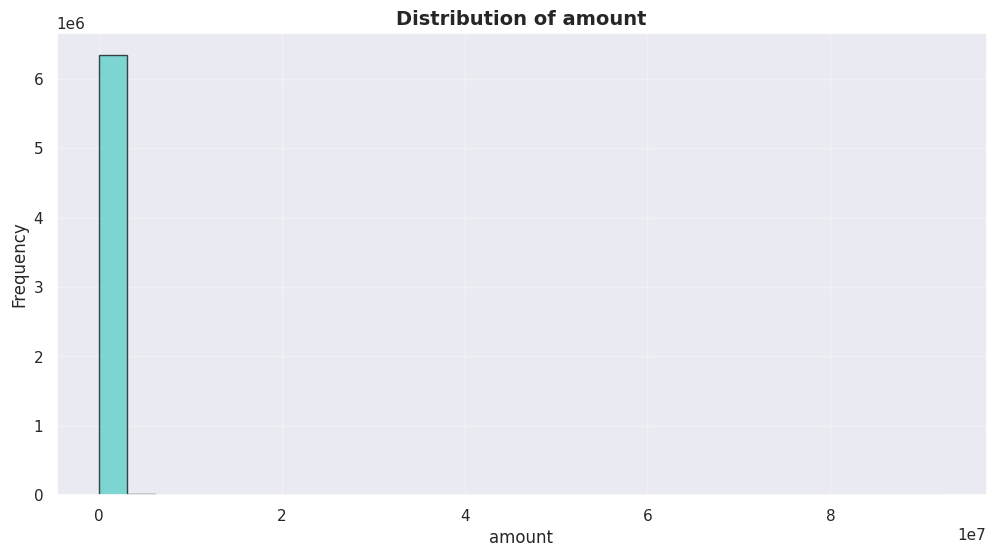

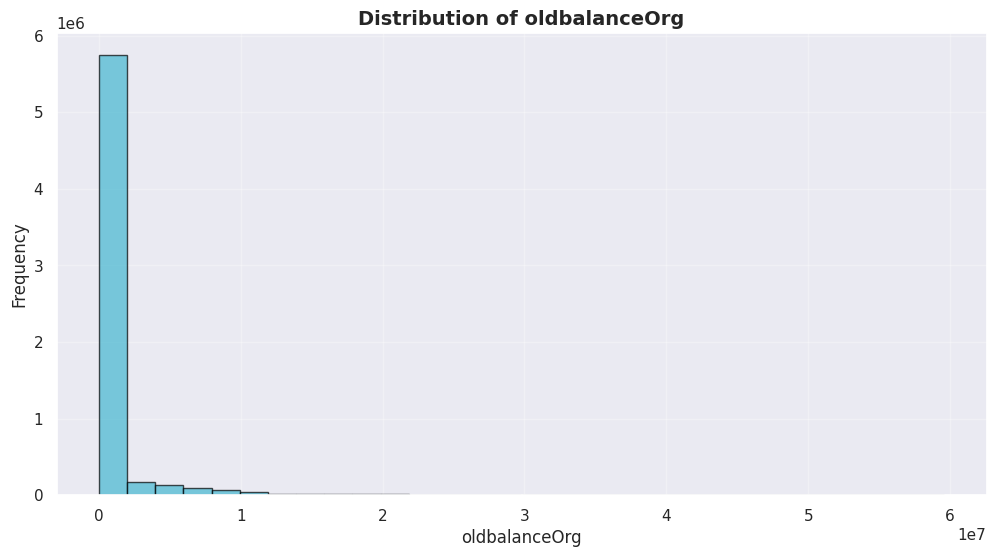

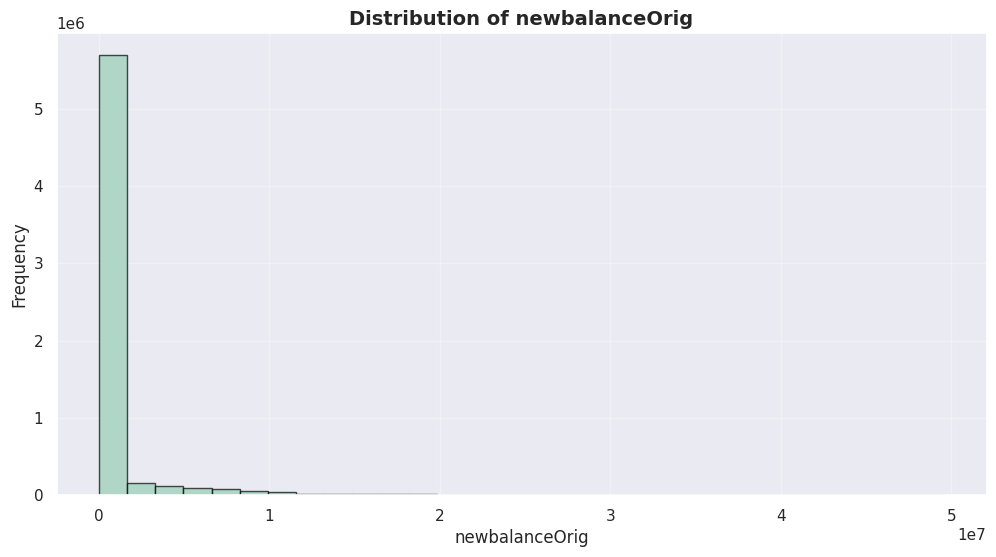

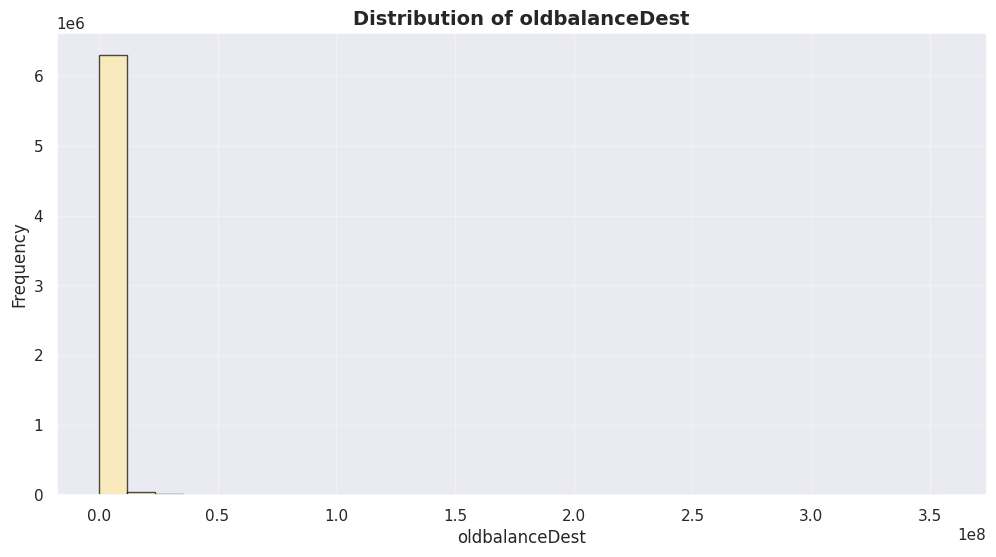

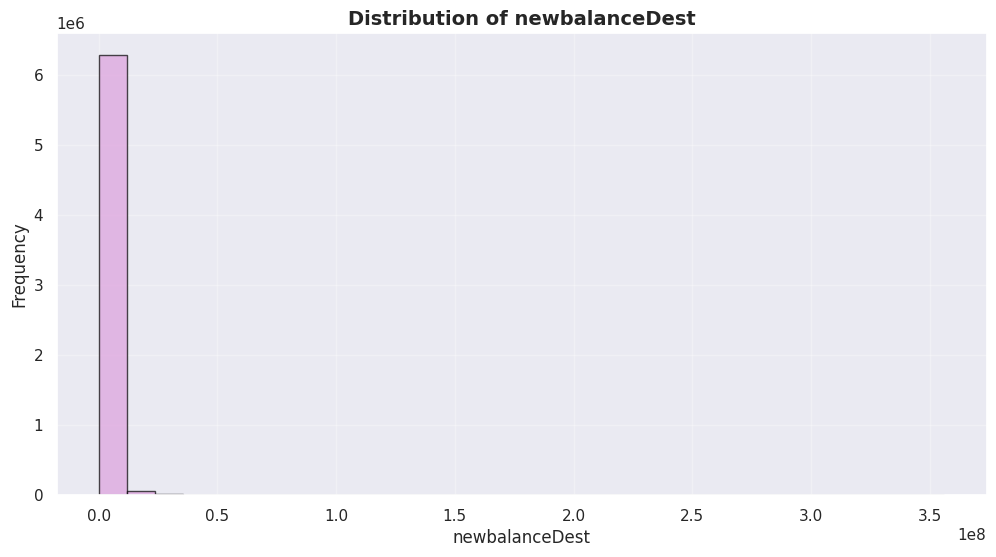

In [ ]:
feature = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

# Vibrant colors
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

for idx, i in enumerate(feature):
    plt.figure(figsize=(12, 6))
    df[i].plot(kind='hist', bins=30,
               color=colors[idx],
               edgecolor='black',
               alpha=0.7)

    plt.title(f'Distribution of {i}', fontsize=14, fontweight='bold')
    plt.xlabel(i, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

We could see some outliers in the plots. So let's work on it!

We'll use Quantile-based Flooring and Capping for these columns!

**Capping** is replacing all higher side values exceeding a certain theoretical maximum or upper control limit (UCL) by the UCL value. Here we'll do 90th percentile for higher values.

**Flooring** is replacing all values falling below a certain theoretical minimum or lower control limit (UCL) by the LCL value. Here we'll do 90th percentile for higher values.



In [ ]:
feature=['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

for i in feature:
    print(i)
    print(df[i].quantile(0.10))
    print(df[i].quantile(0.90))

    print('\n')


amount
4501.3
365423.30900000007


oldbalanceOrg
0.0
1822508.289000007


newbalanceOrig
0.0
1970344.7930000005


oldbalanceDest
0.0
2914266.6690000016


newbalanceDest
0.0
3194869.671000002




Now we'll remove the outlier

In [ ]:
feature=['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

for i in feature:
    lower = df[i].quantile(0.10)
    upper = df[i].quantile(0.90)
    df[i] = np.where(df[i] <lower, lower,df[i])
    df[i] = np.where(df[i] >upper, upper,df[i])
    print('Feature: ',i)
    print('Skewness value: ',df[i].skew())
    print('\n')

Feature:  amount
Skewness value:  0.8046460444556197


Feature:  oldbalanceOrg
Skewness value:  2.249361299814406


Feature:  newbalanceOrig
Skewness value:  2.2262847493216786


Feature:  oldbalanceDest
Skewness value:  1.4173123924260833


Feature:  newbalanceDest
Skewness value:  1.3593024983493058




Now we'll take a look at it after removing outliers

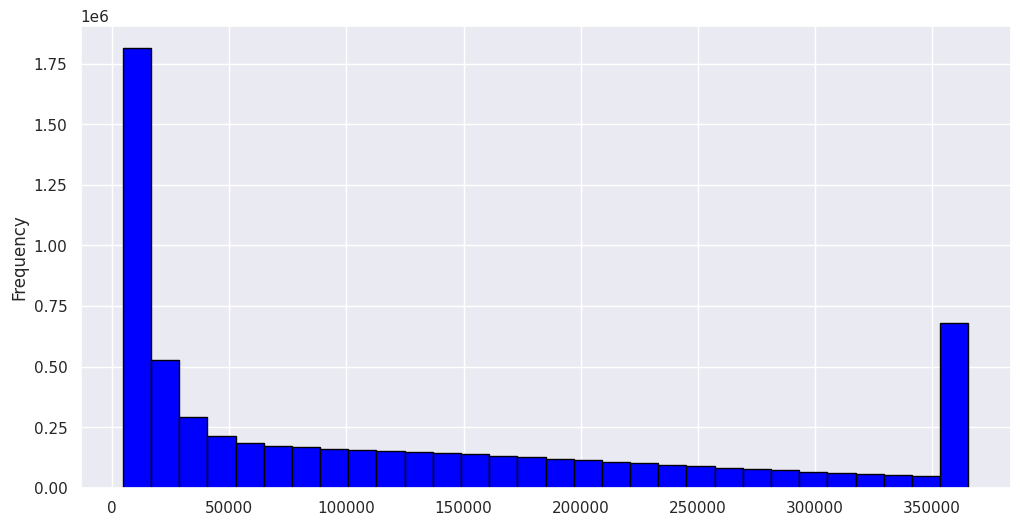

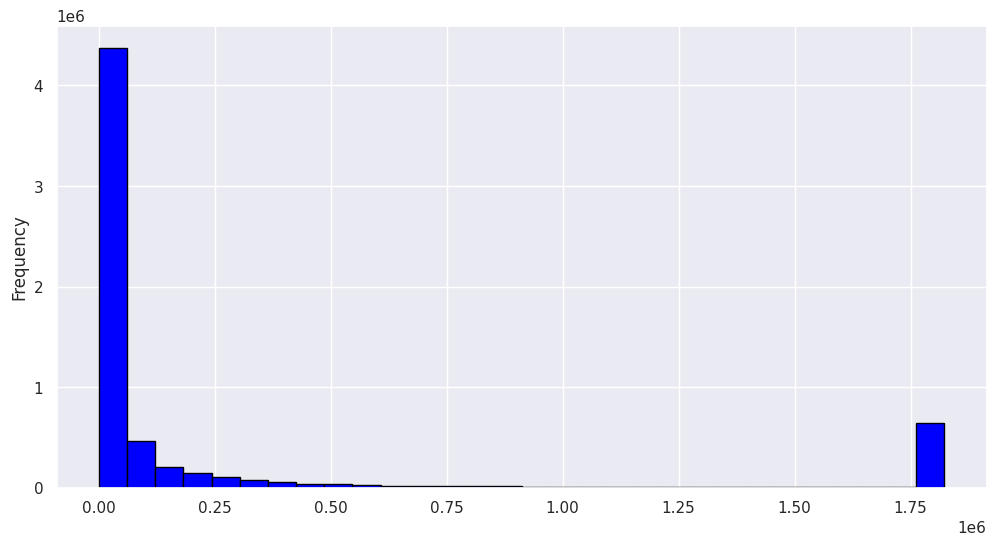

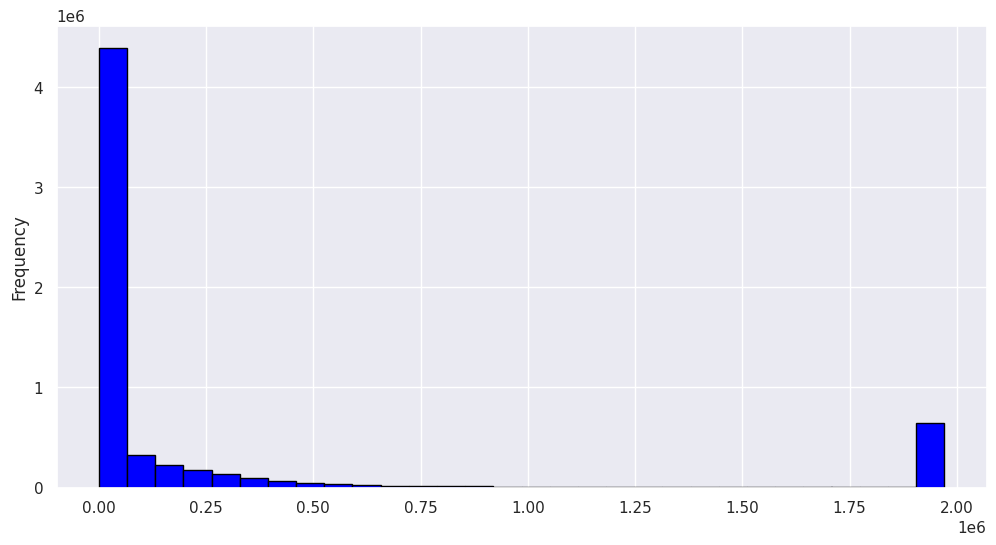

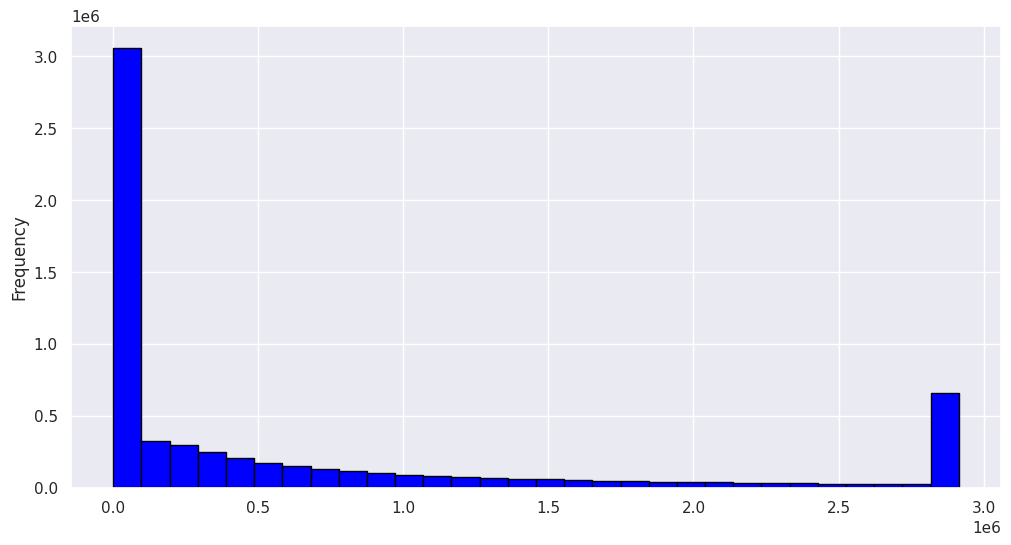

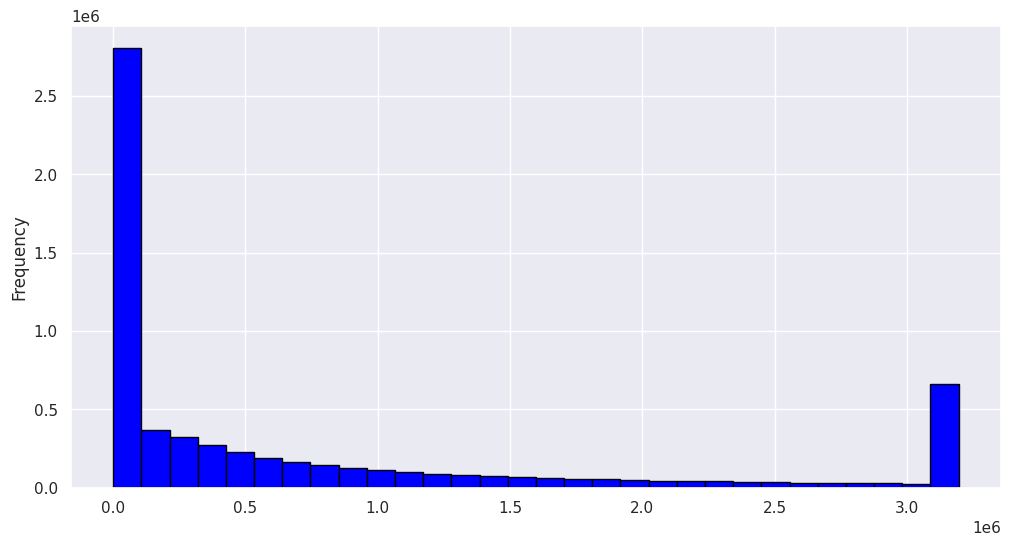

In [ ]:
feature=['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

for i in feature:
    plt.xlabel(i)
    df[i].plot(kind='hist', bins=30, figsize=(12,6), facecolor='blue',edgecolor='black')
    plt.show()

* We have a maximum set of distribution between 150 to 400 of step(hours taken)

**After outlier treatment**

* Amount ranges between 0-35 with more values ranging between 0-75,000. We'll analyze further in the upcoming sections.
* OldbalanceOrg ranges around 0-18 with more frequency around 0-375,000
* NewbalanceOrig ranges around 0-19 with more frequency around 0-375,000
* OldbalanceDest ranges around 0-29 with common values around 0-625,000
* NewbalanceDest ranges around 0-35 with common values around 0-625,000



Columns we'll analyze further:

* type
* amount
* nameDest
* isFraud
* isFlaggedFraud
* step


### Type

We'll look into the type of transactions done

In [ ]:
df.type

,type
0,PAYMENT
1,PAYMENT
2,TRANSFER
3,CASH_OUT
4,PAYMENT
...,...
6362615,CASH_OUT
6362616,TRANSFER
6362617,CASH_OUT
6362618,TRANSFER


In [ ]:
df.type.unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [ ]:
payment = df.type.value_counts()
payment

,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


As we have already seen there are 5 types of transactions happened. We'll plot it using horizontal bar

Text(0.5, 0, 'Frequency')

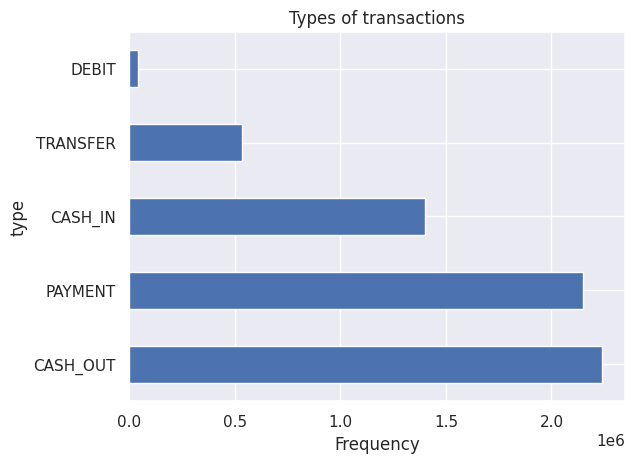

In [ ]:
payment.plot(kind='barh')
plt.title('Types of transactions')
plt.xlabel('Frequency')

Text(0.5, 1.0, 'Types of transactions')

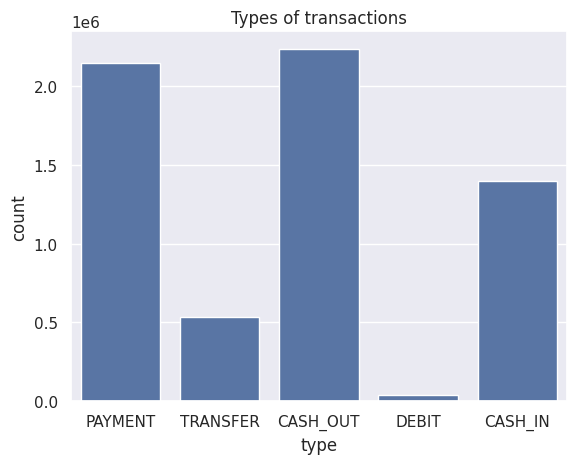

In [ ]:
sns.countplot(x='type', data=df)
plt.title('Types of transactions')

More money has been transacted mostly through cash out followed by payment type.


Now let's look at the relationship with type column with isfraud column

In [ ]:
CrosstabResult=pd.crosstab(index=df.type,columns=df.isFraud)
CrosstabResult


isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [ ]:
#with fraud happened type
CrosstabResult[1]

,1
type,
CASH_IN,0
CASH_OUT,4116
DEBIT,0
PAYMENT,0
TRANSFER,4097


We can see that fraud occurred mostly while during **transfer** or **cashout**. But the numbers indicating fraud happened with fraud not happened is very low. So it'll not be seen in the plot.

Text(0.5, 1.0, 'Transaction Type vs Fraud')

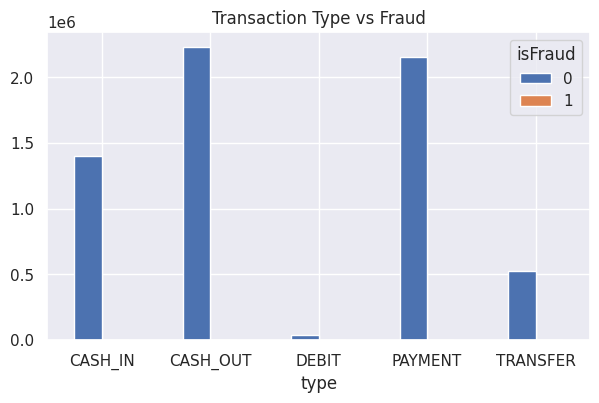

In [ ]:
# Grouped bar chart between TYPE and ISFRAUD
CrosstabResult.plot.bar(figsize=(7,4), rot=0)
plt.title('Transaction Type vs Fraud')

Text(0.5, 1.0, 'Transaction Type vs Fraud')

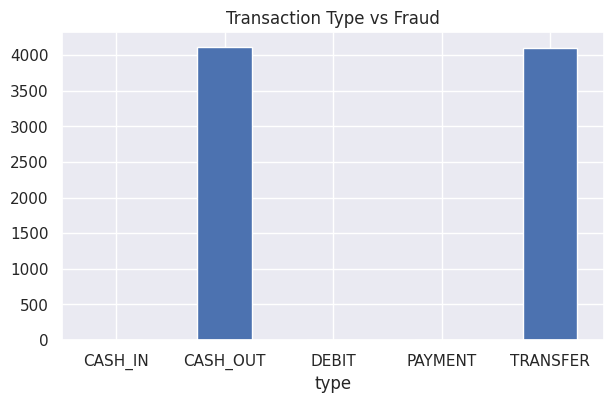

In [ ]:
# Grouped bar chart between TYPE and ISFRAUD with maximizing
CrosstabResult[1].plot.bar(figsize=(7,4), rot=0)
plt.title('Transaction Type vs Fraud')

Text(0.5, 1.0, 'Transacton Type vs Fraud')

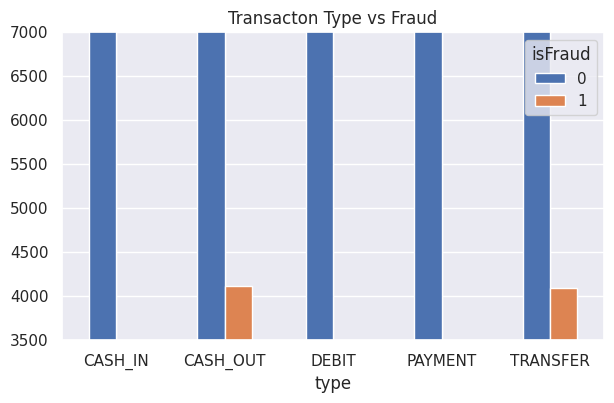

In [ ]:
# Grouped bar chart between TYPE and ISFRAUD by changing ylimit to view isFraud values
CrosstabResult.plot.bar(figsize=(7,4), rot=0)
plt.ylim([3500, 7000])
plt.title('Transacton Type vs Fraud')

Percentage of fraud happened in the cashout type and transfer type mode

In [ ]:
CrosstabResult

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [ ]:
cashout=2233384+4116
cashout_fraud= 4116/(cashout) * 100
cashout_fraud

0.18395530726256984

**0.184 % denotes the percentage of fraud happened in total cashout mode type, which is very less%**

In [ ]:
transfer= 528812+4097
transfer_fraud = 4097/(transfer) * 100
transfer_fraud

0.7687991758442811

**0.769 % denotes the percentage of fraud happened in total tranfer mode type, which is very also less%**

### Amount

In [ ]:
df.amount

,amount
0,9839.640
1,4501.300
2,4501.300
3,4501.300
4,11668.140
...,...
6362615,339682.130
6362616,365423.309
6362617,365423.309
6362618,365423.309


We'll check the minimum and maximum range amount

Text(0.5, 1.0, 'Transacted Amounts Distribution')

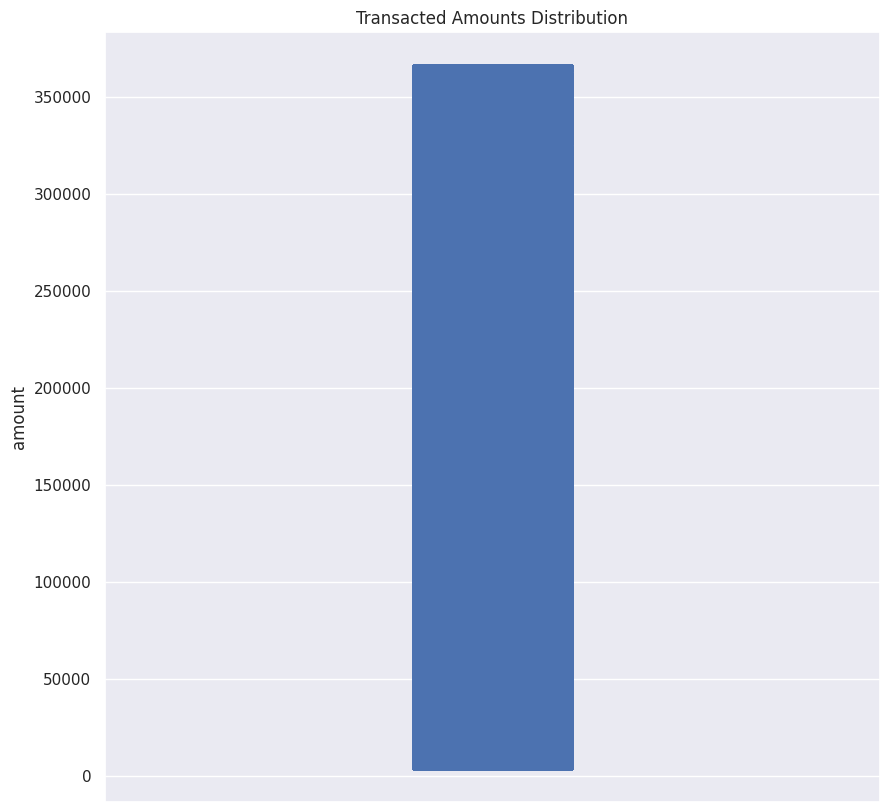

In [ ]:
plt.figure(figsize=(10,10))
sns.stripplot(y=df.amount)
plt.title('Transacted Amounts Distribution')

In [ ]:
print('Minimum: ',df.amount.min())
print('Maximum: ',df.amount.max())

Minimum:  4501.3
Maximum:  365423.30900000007


Insight: **Lowest amount transacted starts from 4500 and highest amount transacted goes upto 365423.31**

We'll check the relationship of amount column with isFraud column

<Figure size 1000x600 with 0 Axes>

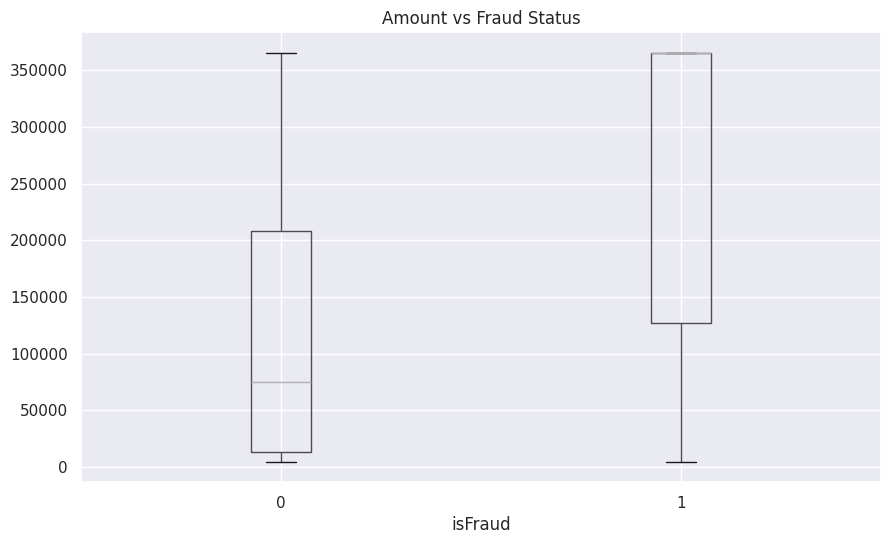

In [ ]:
plt.figure(figsize=(10, 6))
df.boxplot(column='amount', by='isFraud', figsize=(10, 6))
plt.title('Amount vs Fraud Status')
plt.suptitle('')  # Remove default title
plt.show()

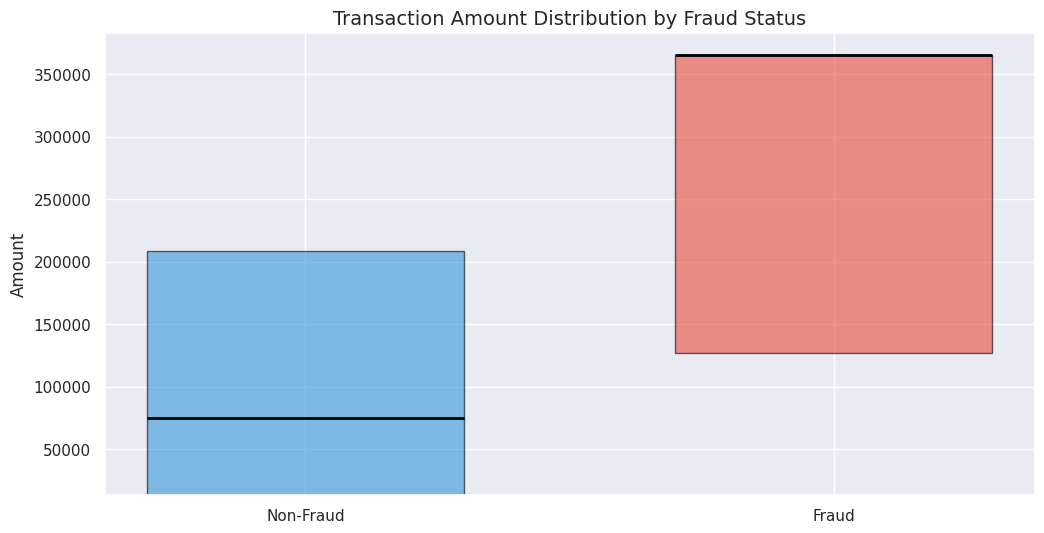

In [ ]:
# Method: Use percentiles for boxplot-like visualization
fig, ax = plt.subplots(figsize=(12, 6))

fraud_groups = df.groupby('isFraud')['amount']
positions = [0, 1]
colors = ['#3498DB', '#E74C3C']

for pos, (fraud_val, group) in zip(positions, fraud_groups):
    # Calculate percentiles
    q25, q50, q75 = group.quantile([0.25, 0.5, 0.75])
    min_val, max_val = group.min(), group.max()

    # Draw box manually
    ax.bar(pos, q75-q25, bottom=q25, width=0.6,
           color=colors[pos], alpha=0.6, edgecolor='black')
    ax.hlines(q50, pos-0.3, pos+0.3, colors='black', linewidth=2)

ax.set_xticks(positions)
ax.set_xticklabels(['Non-Fraud', 'Fraud'])
ax.set_title('Transaction Amount Distribution by Fraud Status', fontsize=14)
ax.set_ylabel('Amount')
plt.show()

Insight: **High amount transacted between 1.3-3.6 were flagged as fraudulent**

### isFlaggedFraud

isFlaggedFraud denotes the transactions that are assumed to be fraud.

In [ ]:
df.isFlaggedFraud.value_counts()

,count
isFlaggedFraud,
0,6362604
1,16


Insight: From a total of 6.3M records only 16 were assumed and flagged as fraud, which is actually a very low number. The actual fraud happened has a very higher value when compared to isFlaggedFraud column.

Now let's look at how many values they assumed and flagged as fraud is actually correct

In [ ]:
flagged_fraud_records = df[(df.isFraud==1) & (df.isFlaggedFraud==1)]
flagged_fraud_records

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2736446,212,TRANSFER,365423.309,C728984460,1822508.289,1970344.793,C639921569,0.0,0.0,1,1
3247297,250,TRANSFER,365423.309,C1100582606,1343002.080,1343002.080,C1147517658,0.0,0.0,1,1
3760288,279,TRANSFER,365423.309,C1035541766,536624.410,536624.410,C1100697970,0.0,0.0,1,1
5563713,387,TRANSFER,365423.309,C908544136,1822508.289,1970344.793,C891140444,0.0,0.0,1,1
5996407,425,TRANSFER,365423.309,C689608084,1822508.289,1970344.793,C1392803603,0.0,0.0,1,1
5996409,425,TRANSFER,365423.309,C452586515,1822508.289,1970344.793,C1109166882,0.0,0.0,1,1
6168499,554,TRANSFER,365423.309,C193696150,1822508.289,1970344.793,C484597480,0.0,0.0,1,1
6205439,586,TRANSFER,353874.220,C1684585475,353874.220,353874.220,C1770418982,0.0,0.0,1,1
6266413,617,TRANSFER,365423.309,C786455622,1822508.289,1970344.793,C661958277,0.0,0.0,1,1
6281482,646,TRANSFER,365423.309,C19004745,1822508.289,1970344.793,C1806199534,0.0,0.0,1,1


In [ ]:
flagged_fraud_records.shape

(16, 11)

Insight: This denotes that all the records which were flagged as fraud were correct.

Now let's look at the percentage of records which were flagged as fraud to the total fraud that happened

In [ ]:
total_fraud= df[df.isFraud ==1]
total_fraud = total_fraud.shape[0]
total_fraud

8213

In [ ]:
total_isflaggedFraud= flagged_fraud_records.shape[0]
total_isflaggedFraud

16

In [ ]:
flagged_percent = total_isflaggedFraud/total_fraud * 100
print('Percentage of flagged fraud: ',round(flagged_percent,3))

unflagged_percent= (total_fraud-total_isflaggedFraud)/total_fraud * 100
print('Percentage of incorrectly flagged fraud: ',round(unflagged_percent,3))

Percentage of flagged fraud:  0.195
Percentage of incorrectly flagged fraud:  99.805


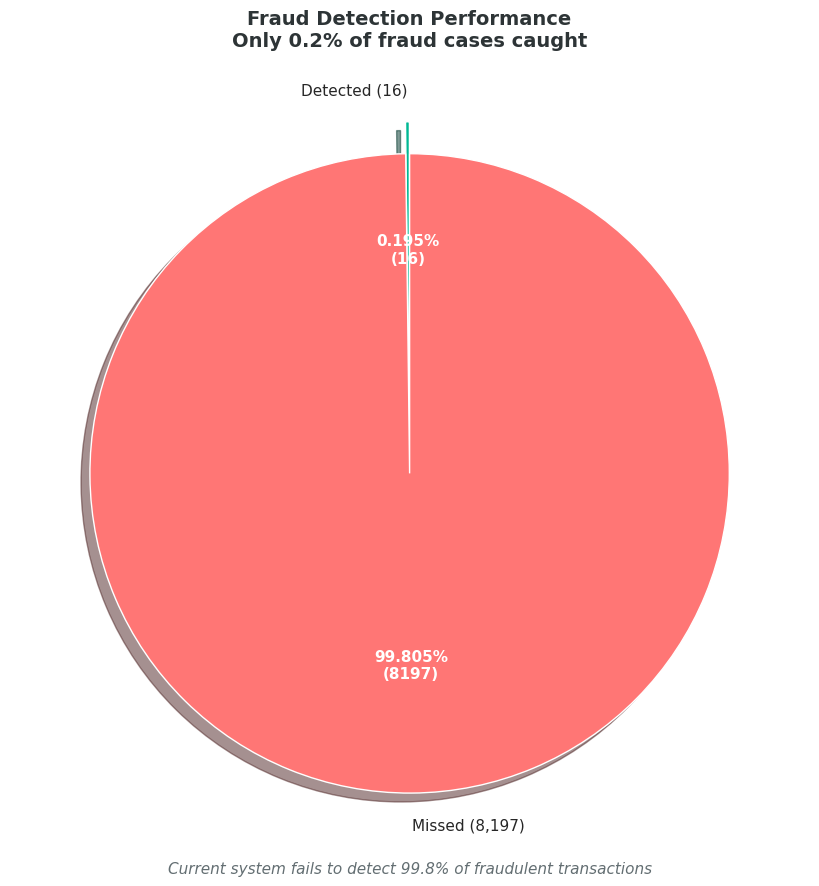

In [ ]:
# Data
flagged = 16
missed = 8197

fig, ax = plt.subplots(figsize=(9, 9))

# Create pie
wedges, texts, autotexts = ax.pie(
    [flagged, missed],
    labels=['Detected (16)', 'Missed (8,197)'],
    colors=['#00B894', '#FF7675'],
    autopct=lambda pct: f'{pct:.3f}%\n({int(pct/100.*(flagged+missed))})',
    startangle=90,
    explode=(0.1, 0),
    shadow=True,
    textprops={'fontsize': 11}
)

# Style percentages
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Title with insight
ax.set_title('Fraud Detection Performance\nOnly 0.2% of fraud cases caught',
             fontsize=14, fontweight='bold', pad=20, color='#2D3436')

# Add subtitle
plt.figtext(0.5, 0.02,
            'Current system fails to detect 99.8% of fraudulent transactions',
            ha='center', fontsize=11, style='italic', color='#636E72')

plt.tight_layout()
plt.show()

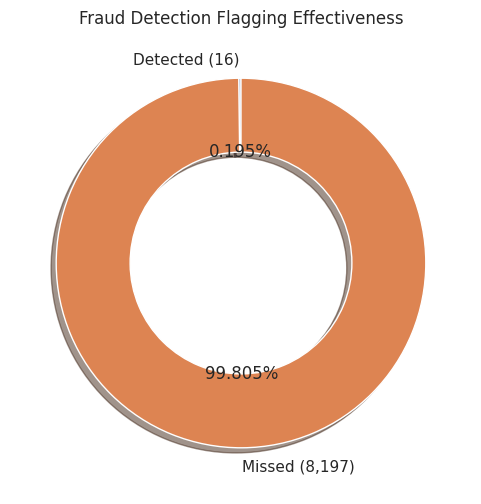

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))

ax.pie(
    [flagged, missed],
    labels=['Detected (16)', 'Missed (8,197)'],
    autopct='%1.3f%%',
    startangle=90,
    shadow=True,
    wedgeprops=dict(width=0.4)
)

plt.title('Fraud Detection Flagging Effectiveness')
plt.show()

Insight: The current fraud detection system flagged only 16 out of 8,213 fraud cases, missing 99.8% of all fraudulent transactions. This represents a critical system failure requiring immediate model improvement.

### isFraud

In [ ]:
total_transactions = df.shape[0]

fraud_transaction = df[df.isFraud==1].shape[0]

fraud_percent= fraud_transaction/total_transactions * 100
fraud_percent



0.12908204481801522

In [ ]:
print('Total transactions: ',total_transactions)
print('Total fraudulent transactions: ',fraud_transaction)
print("Total fraudulent transactions percentage: ",round(fraud_percent,2),"%")

Total transactions:  6362620
Total fraudulent transactions:  8213
Total fraudulent transactions percentage:  0.13 %


In [ ]:
fraud_amount= df[df.isFraud==1]
fraud_amount=fraud_amount.sort_values(by=['amount'],ascending=False)
fraud_amount


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362619,743,CASH_OUT,365423.309,C1280323807,850002.520,0.0,C873221189,2914266.669,3194869.671,1,0
6362618,743,TRANSFER,365423.309,C1685995037,850002.520,0.0,C2080388513,0.000,0.000,1,0
6362617,743,CASH_OUT,365423.309,C1162922333,1822508.289,0.0,C1365125890,68488.840,3194869.671,1,0
6362601,742,CASH_OUT,365423.309,C1614818636,652993.910,0.0,C362803701,0.000,652993.910,1,0
6362600,742,TRANSFER,365423.309,C40604503,652993.910,0.0,C1166857907,0.000,0.000,1,0
...,...,...,...,...,...,...,...,...,...,...,...
1030453,65,TRANSFER,4501.300,C270115029,215.830,0.0,C1574358644,0.000,0.000,1,0
6202688,583,TRANSFER,4501.300,C469202951,1583.280,0.0,C1107076598,0.000,0.000,1,0
251,1,TRANSFER,4501.300,C1420196421,2806.000,0.0,C972765878,0.000,0.000,1,0
3,1,CASH_OUT,4501.300,C840083671,181.000,0.0,C38997010,21182.000,0.000,1,0


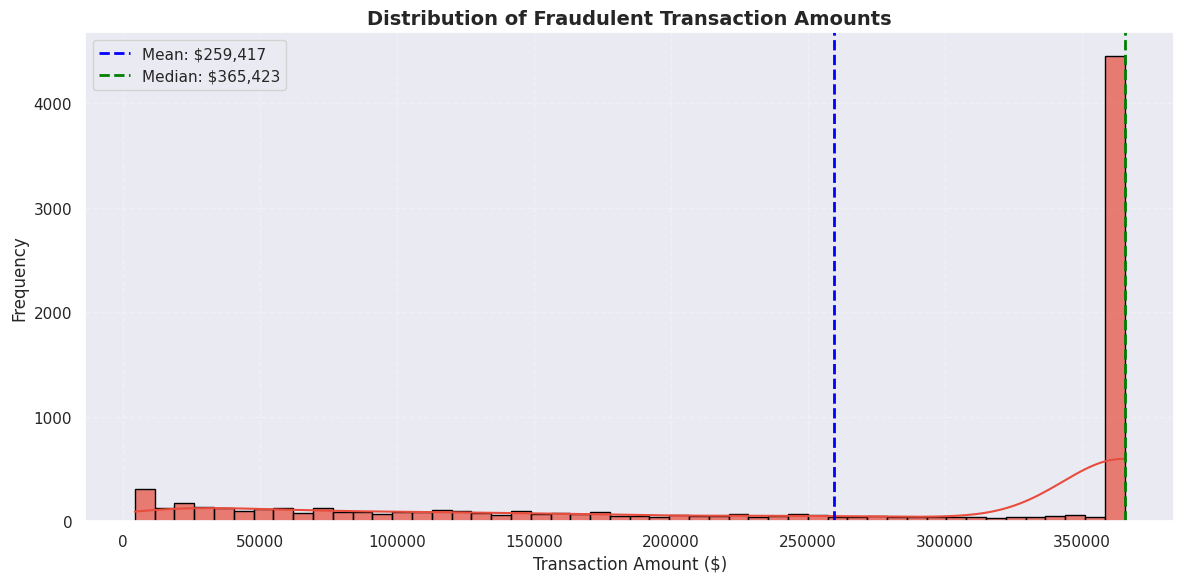

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# Histogram with density curve
sns.histplot(data=fraud_amount, x='amount', bins=50, kde=True,
             color='#E74C3C', edgecolor='black', alpha=0.7, ax=ax)

ax.set_title('Distribution of Fraudulent Transaction Amounts', fontsize=14, fontweight='bold')
ax.set_xlabel('Transaction Amount ($)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')

# Statistics
mean_amt = fraud_amount['amount'].mean()
median_amt = fraud_amount['amount'].median()
ax.axvline(mean_amt, color='blue', linestyle='--', linewidth=2, label=f'Mean: ${mean_amt:,.0f}')
ax.axvline(median_amt, color='green', linestyle='--', linewidth=2, label=f'Median: ${median_amt:,.0f}')
ax.legend()

plt.tight_layout()
plt.show()

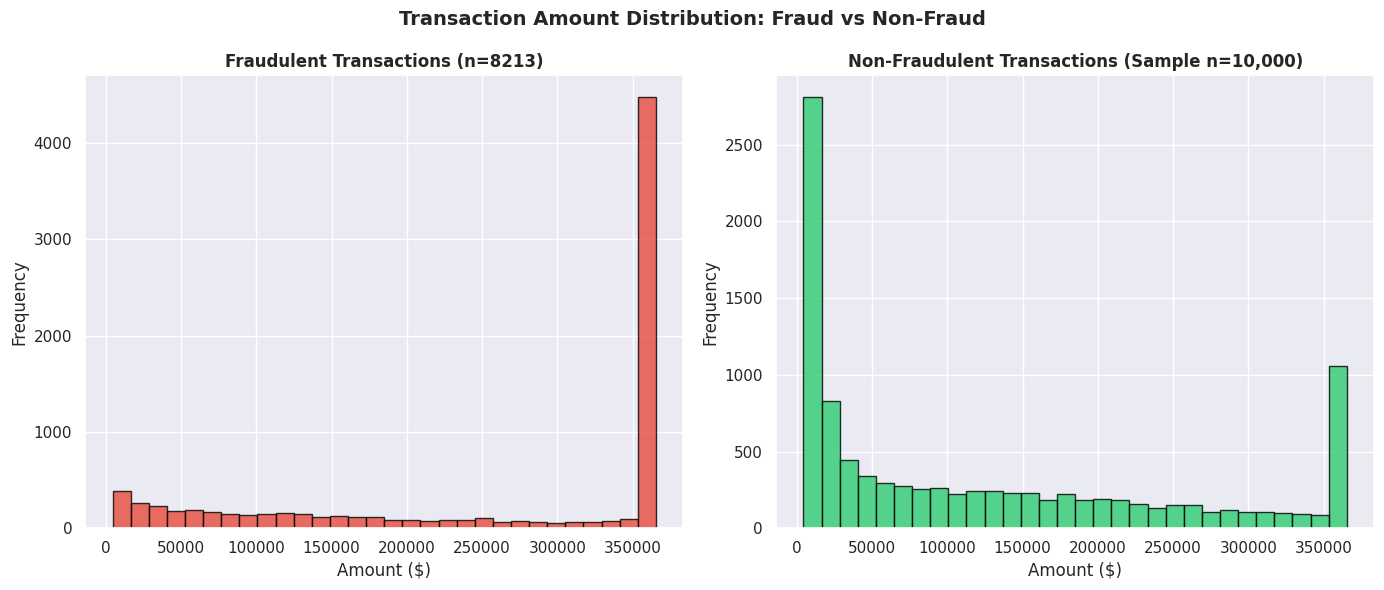

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Non-fraud amounts (sample for speed)
non_fraud_sample = df[df['isFraud'] == 0]['amount'].sample(10000, random_state=42)

# Plot 1: Fraud
axes[0].hist(fraud_amount['amount'], bins=30, color='#E74C3C',
             edgecolor='black', alpha=0.8)
axes[0].set_title(f'Fraudulent Transactions (n={len(fraud_amount)})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')

# Plot 2: Non-Fraud (sampled)
axes[1].hist(non_fraud_sample, bins=30, color='#2ECC71',
             edgecolor='black', alpha=0.8)
axes[1].set_title(f'Non-Fraudulent Transactions (Sample n=10,000)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Transaction Amount Distribution: Fraud vs Non-Fraud',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Insight: Fraud transactions cluster in high-value ranges

Business Impact: High-value transactions need extra scrutiny

# nameDest

In [ ]:
fraudster= df.nameDest.value_counts()
fraudster

,count
nameDest,
C1286084959,113
C985934102,109
C665576141,105
C2083562754,102
C248609774,101
...,...
M367627425,1
M1902904124,1
M242332837,1


Since we have large number of unique values, we'll take only top 10 fraudster id name.

Taking the top 10 fraudster ids

In [ ]:
fraudster[:10]

,count
nameDest,
C1286084959,113
C985934102,109
C665576141,105
C2083562754,102
C248609774,101
C1590550415,101
C1789550256,99
C451111351,99
C1360767589,98


Text(0.5, 1.0, 'Top 10 Fraudster IDs')

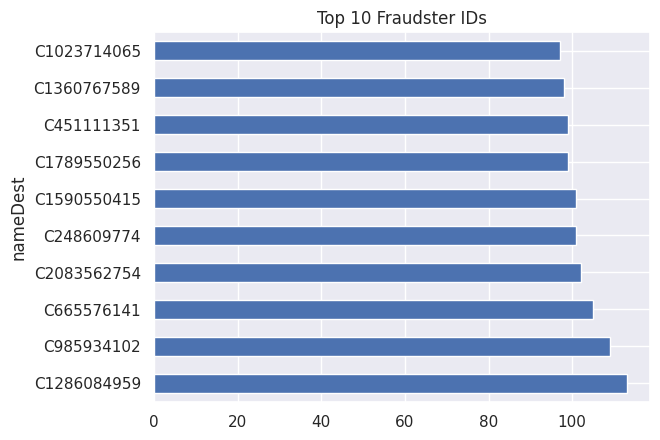

In [ ]:
fraudster[:10].plot(kind='barh')
plt.title('Top 10 Fraudster IDs')

### Balance anomalies

Text(0.5, 1.0, 'Balance Pattern Anomalies')

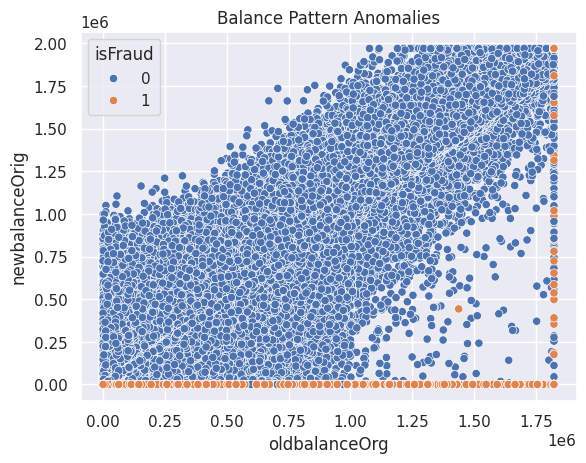

In [ ]:
sns.scatterplot(
    x='oldbalanceOrg',
    y='newbalanceOrig',
    hue='isFraud',
    data=df
)
plt.title('Balance Pattern Anomalies')

### Step
Represents a unit of time where 1 step equals 1 hour

Text(0.5, 1.0, 'Fraud Transactions by Hour')

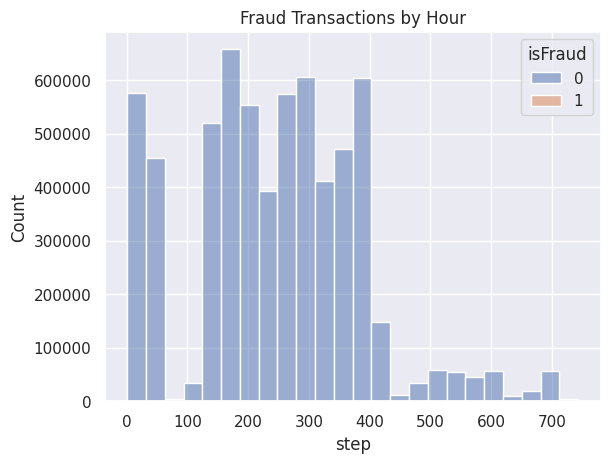

In [ ]:
#Time pattern
sns.histplot(data=df, x='step', hue='isFraud', bins=24)
plt.title('Fraud Transactions by Hour')

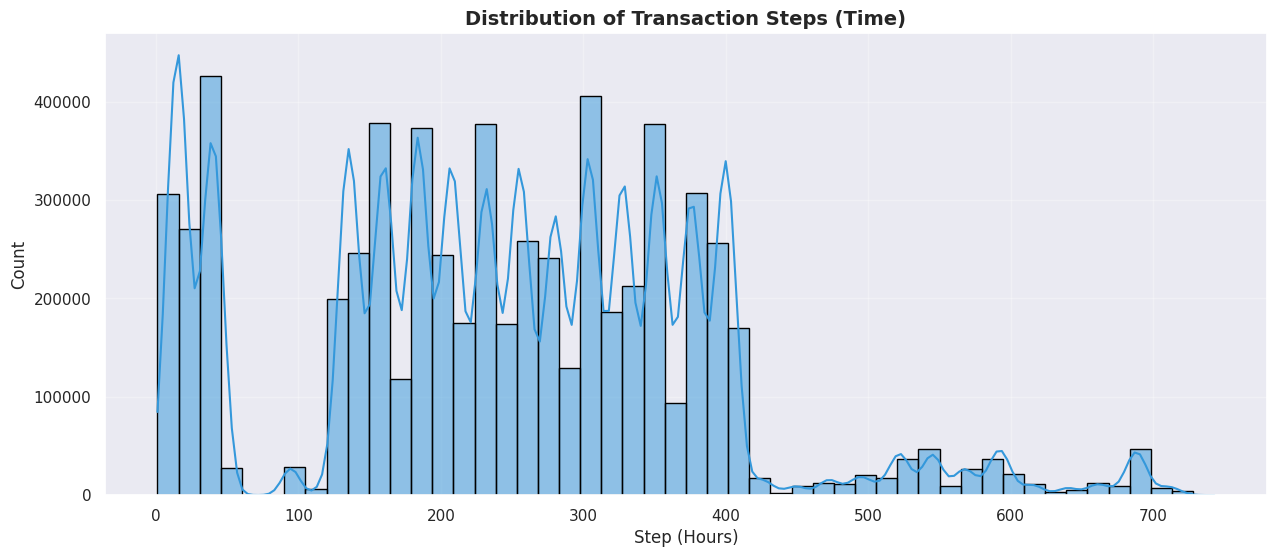

In [ ]:
plt.figure(figsize=(15, 6))
sns.histplot(df['step'], bins=50, kde=True, color='#3498DB', edgecolor='black')

plt.title('Distribution of Transaction Steps (Time)', fontsize=14, fontweight='bold')
plt.xlabel('Step (Hours)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

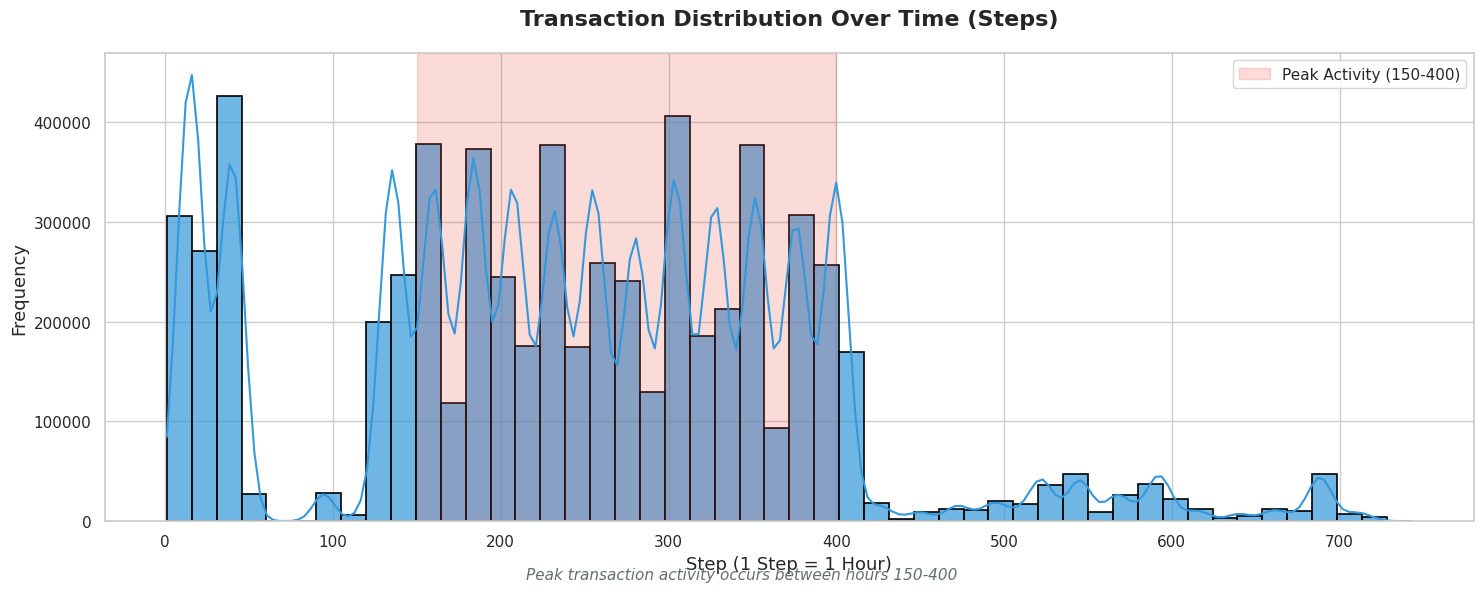

In [ ]:
# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(15, 6))

# Distplot
sns.histplot(df['step'], bins=50, kde=True, color='#3498DB',
             edgecolor='black', alpha=0.7, linewidth=1.2)

# Title and labels
plt.title('Transaction Distribution Over Time (Steps)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Step (1 Step = 1 Hour)', fontsize=13)
plt.ylabel('Frequency', fontsize=13)

# Highlight peak region
plt.axvspan(150, 400, alpha=0.2, color='#E74C3C', label='Peak Activity (150-400)')
plt.legend()

# Add annotation
plt.figtext(0.5, 0.02, 'Peak transaction activity occurs between hours 150-400',
            ha='center', fontsize=11, style='italic', color='#636E72')

plt.tight_layout()
plt.show()

Insight: Peak transaction activity occurs between hours 150 to 400

### Correlation between features

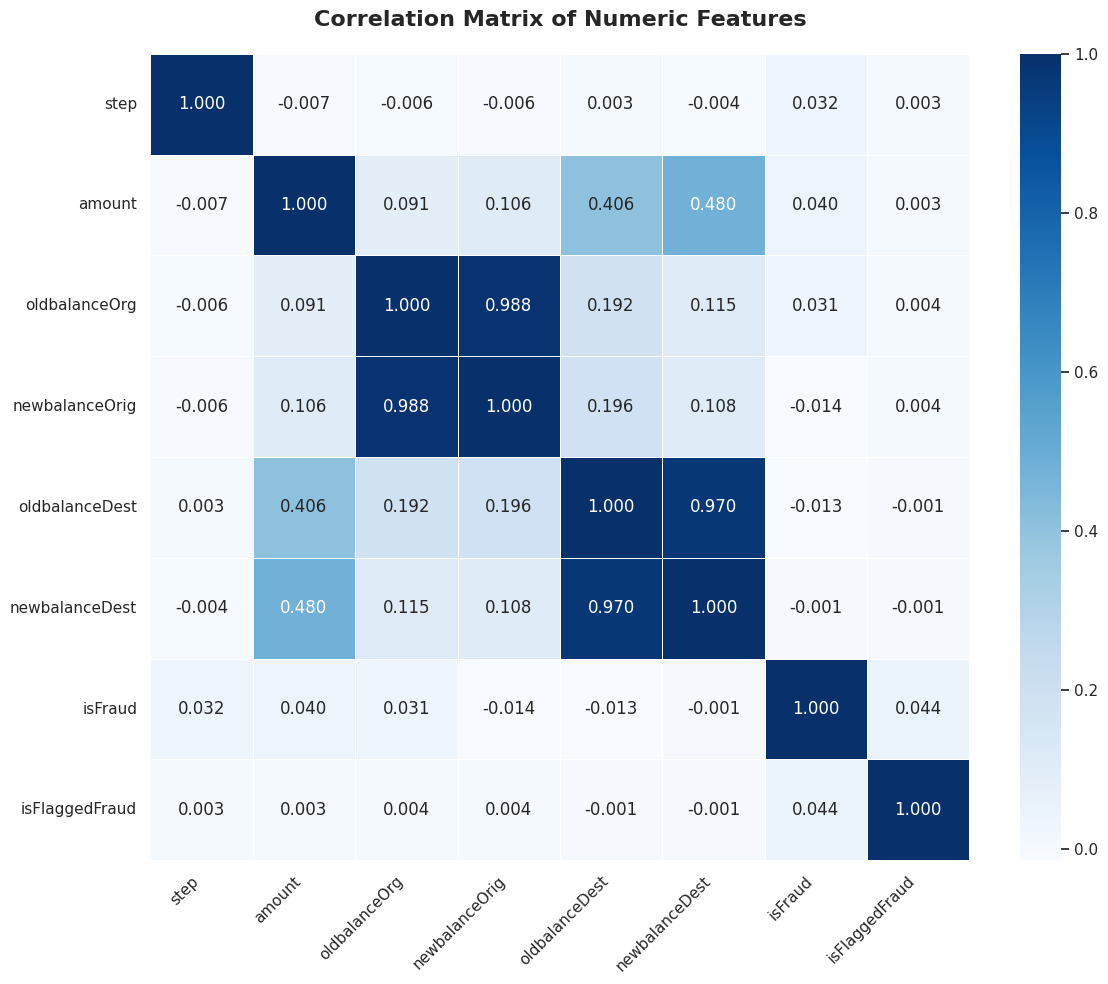

In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate correlation
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr,
            xticklabels=corr.columns,
            yticklabels=corr.columns,
            annot=True,
            cmap='Blues',
            fmt=".3f",
            linewidths=0.5)

plt.title('Correlation Matrix of Numeric Features', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Insight: There is a high correlation between newbalanceOrig and oldbalanceOrg.

Also, between newbalanceDest and oldbalanceDest.

Apart from that, we have a relatively high correlation between amount and newbalanceDest and amount with oldbalanceDest

### Analysis insights

**1. What is the fraud percent that has happened in the overall transaction ?**

 Totally there is **8213** fraud transactions happened which constitutes around **0.13%** of total transactions happened

**2. Under which type of transfer payment type fraud has occurred mostly.**

Fraud has happened only in cashout and transfer type. **0.183 %**  fraud happened in total cashout mode type and **0.769 %**  fraud happened in total transfer mode type

**3. Were we able to mark the fraud transaction as isFlaggedFraud?**
No. Only **16** records of the 63000 records were flagged as fraud which is very less that constitutes to **0.195 %** of the total fraud transactions.

**4. What is the percentage of incorrect flagged fraud records?**

We have around **8197** records which are incorrectly flagged  as 0 which constitutes **99.805 %** of total fraud records

**5. Were all the isFlaggedFraud records that are marked as fraud is correct?**
**Yes**. All the 16 transactions that are flagged as fraud is actually fraud transactions

**6. At what amount range, fraud has happened?**  
The fraud amount transaction ranges between 1.3-360K with most occurred in the range  **340,000-360,000**.

##  Key EDA Insights

- Fraudulent transactions are rare but high-risk events  
- Transaction amount plays a critical role in detecting anomalies  
- Certain transaction types are more susceptible to fraud  
- Irregular balance patterns are strong indicators of fraudulent activity  

### Data Preprocessing

In [ ]:
# Create copy for processing
df_processed = fraud_df.copy()

In [ ]:
# Time-based features
df_processed['hour'] = df_processed['step'] % 24
df_processed['day'] = (df_processed['step'] // 24) % 7
df_processed.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,day
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1,0


In [ ]:
# Balance change features
df_processed['balance_change_orig'] = df_processed['newbalanceOrig'] - df_processed['oldbalanceOrg']
df_processed['balance_change_dest'] = df_processed['newbalanceDest'] - df_processed['oldbalanceDest']
df_processed.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,day,balance_change_orig,balance_change_dest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1,0,-9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1,0,-1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1,0,-181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,1,0,-181.00,-21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1,0,-11668.14,0.0


In [ ]:
# Transaction features
df_processed['amount_to_oldbalance_ratio'] = df_processed['amount'] / (df_processed['oldbalanceOrg'] + 1)
df_processed['amount_to_newbalance_ratio'] = df_processed['amount'] / (df_processed['newbalanceOrig'] + 1)
df_processed.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,day,balance_change_orig,balance_change_dest,amount_to_oldbalance_ratio,amount_to_newbalance_ratio
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1,0,-9839.64,0.0,0.057834,0.061384
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1,0,-1864.28,0.0,0.087731,0.096168
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1,0,-181.00,0.0,0.994505,181.000000
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,1,0,-181.00,-21182.0,0.994505,181.000000
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1,0,-11668.14,0.0,0.280788,0.390410


In [ ]:
# Anomaly indicators
df_processed['zero_balance_after'] = (df_processed['newbalanceOrig'] == 0).astype(int)
df_processed['full_amount_transfer'] = (df_processed['amount'] == df_processed['oldbalanceOrg']).astype(int)
df_processed.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,day,balance_change_orig,balance_change_dest,amount_to_oldbalance_ratio,amount_to_newbalance_ratio,zero_balance_after,full_amount_transfer
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1,0,-9839.64,0.0,0.057834,0.061384,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1,0,-1864.28,0.0,0.087731,0.096168,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1,0,-181.00,0.0,0.994505,181.000000,1,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,1,0,-181.00,-21182.0,0.994505,181.000000,1,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1,0,-11668.14,0.0,0.280788,0.390410,0,0


In [ ]:
# Encode categorical
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()
scaler = StandardScaler()

df_processed['type'] = le.fit_transform(df_processed['type'])

#### Select Features & Target

In [ ]:
# Drop non-numeric and ID columns
features_to_drop = ['step','nameOrig', 'nameDest', 'isFlaggedFraud']
X = df_processed.drop(columns=features_to_drop + ['isFraud'])
y = df_processed['isFraud']

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Fraud rate: {y.mean()*100:.3f}%")

Features shape: (6362620, 14)
Target distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud rate: 0.129%


###  Predictive Modeling

Fraud detection is treated as a binary classification problem.

Given the imbalance in the dataset, techniques such as SMOTE are applied to improve model performance.

Models are trained to distinguish between legitimate and fraudulent transactions.

#### Train-Test Split

In [ ]:
# Stratified split to maintain fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Fraud rate: {y_train.mean()*100:.3f}%")
print(f"Test: {X_test.shape}, Fraud rate: {y_test.mean()*100:.3f}%")

Train: (5090096, 14), Fraud rate: 0.129%
Test: (1272524, 14), Fraud rate: 0.129%


#### Handle Class Imbalance
 SMOTE + RandomUnderSampler

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Resampling strategy
resampling = ImbPipeline([
    ('over', SMOTE(sampling_strategy=0.1, random_state=42)),      # Oversample to 10:1
    ('under', RandomUnderSampler(sampling_strategy=0.5, random_state=42))  # Then undersample to 2:1
])

X_train_resampled, y_train_resampled = resampling.fit_resample(X_train, y_train)

print("After resampling:")
print(f"Train shape: {X_train_resampled.shape}")
print(f"Fraud rate: {y_train_resampled.mean()*100:.1f}%")
print(f"Class distribution:\n{pd.Series(y_train_resampled).value_counts()}")

After resampling:
Train shape: (1525056, 14)
Fraud rate: 33.3%
Class distribution:
isFraud
0    1016704
1     508352
Name: count, dtype: int64


#### Model Development

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, average_precision_score

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Models
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(
        scale_pos_weight=99,  # (6.3M - 8213) / 8213 ≈ 99:1
        max_depth=6,
        learning_rate=0.1,
        n_estimators=200,
        eval_metric='aucpr',
        random_state=42
    )
}

In [ ]:
# Train and evaluate
results = {}
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)

    # Train
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train_resampled)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_resampled, y_train_resampled)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    # Evaluate
    print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))

    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")

    results[name] = {
        'model': model,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'y_proba': y_proba
    }


Training: Logistic Regression
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1270881
       Fraud       0.95      1.00      0.97      1643

    accuracy                           1.00   1272524
   macro avg       0.97      1.00      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC: 0.9998
PR-AUC: 0.9963

Training: Random Forest
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1270881
       Fraud       0.97      1.00      0.98      1643

    accuracy                           1.00   1272524
   macro avg       0.99      1.00      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC: 0.9994
PR-AUC: 0.9969

Training: XGBoost
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1270881
       Fraud       0.83      1.00      0.91      1643

    accuracy                           1.00  

#### Model Interpretation with SHAP

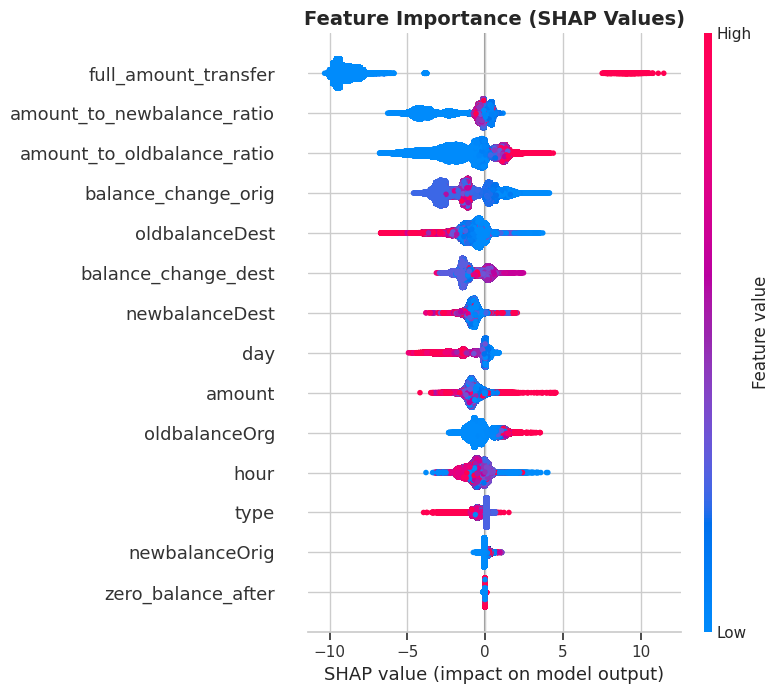

In [ ]:
import shap
# Use best model
best_model = results['XGBoost']['model']

# SHAP analysis
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=X.columns, show=False)
plt.title('Feature Importance (SHAP Values)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Force plot for single prediction
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0], feature_names=X.columns)

## Model Evaluation

Evaluation focuses on:

- Recall (to capture fraudulent transactions)
- Precision (to reduce false positives)
- F1 Score

Missing a fraudulent transaction has a higher cost than incorrectly flagging a legitimate one.

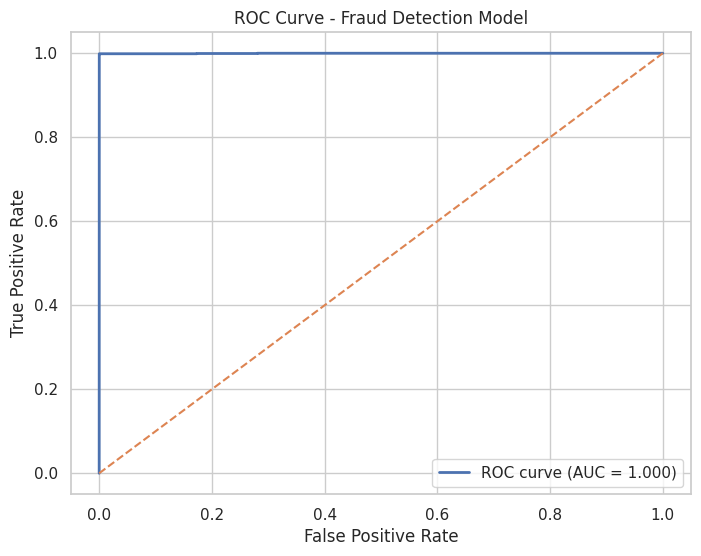

In [ ]:
from sklearn.metrics import roc_curve, auc

# Probability predictions
y_prob2 = model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob2)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Fraud Detection Model')
plt.legend(loc='lower right')
plt.show()

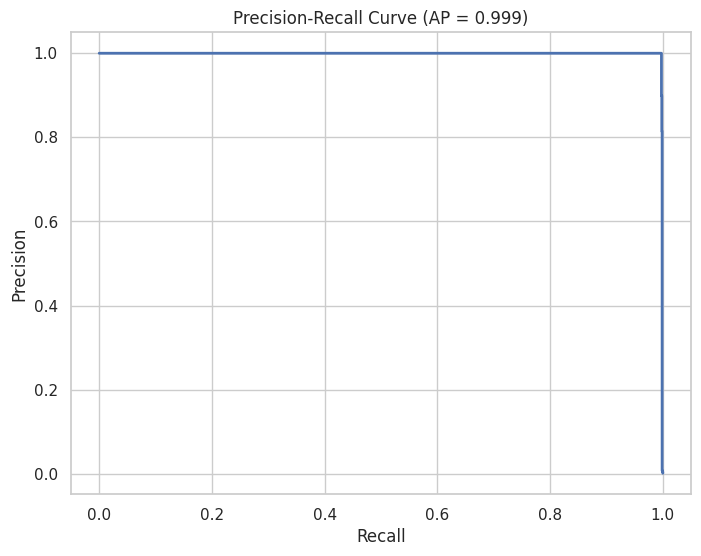

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_prob2)
ap = average_precision_score(y_test, y_prob2)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (AP = {ap:.3f})')
plt.show()

### Insight: ROC Curve Performance

The ROC curve illustrates the model’s ability to distinguish between fraudulent and legitimate transactions across different classification thresholds.

The Area Under the Curve (AUC) summarizes overall discrimination performance.

- AUC close to **1.0** → excellent separation
- AUC around **0.5** → no predictive power

A higher AUC indicates stronger fraud detection capability.

## 🏦 Business Recommendations

Based on the analysis:

#### 1. Real-Time Monitoring
Deploy models to flag suspicious transactions instantly.

#### 2. Risk-Based Alerts
Prioritize high-risk transactions for investigation.

#### 3. Behavioral Tracking
Monitor unusual transaction patterns across accounts.

#### 4. Fraud Prevention Strategy
Continuously retrain models to adapt to evolving fraud tactics.

## ✅ Conclusion

This project demonstrates how machine learning can be applied to detect fraudulent transactions and support banking risk management systems.

The insights generated can help financial institutions reduce fraud losses and improve operational efficiency.

# References

* [https://www.pluralsight.com/guides/cleaning-up-data-from-outliers](https://www.pluralsight.com/guides/cleaning-up-data-from-outliers)
* [analyticsvidhya.com/blog/2021/05/detecting-and-treating-outliers-treating-the-odd-one-out/](http://analyticsvidhya.com/blog/2021/05/detecting-and-treating-outliers-treating-the-odd-one-out/)
* [https://www.analyticsvidhya.com/blog/2020/07/univariate-analysis-visualization-with-illustrations-in-python/](https://www.analyticsvidhya.com/blog/2020/07/univariate-analysis-visualization-with-illustrations-in-python/)
* [https://jovian.ai/aakashns-6l3/us-accidents-analysis](http://jovian.ai/aakashns-6l3/us-accidents-analysis)
* https://thinkingneuron.com/how-to-visualize-the-relationship-between-two-categorical-variables-in-python/

